In [1]:
import rich
import logging
import glob

import matplotlib.pyplot as plt

import awkward as ak
import numpy as np
import pandas as pd
import time


from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data

import re
from collections import defaultdict


%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.12/site-packages/tornado

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# settings


In [41]:
deepgrey = '#CCCCCC'
deeplightblue =  '#07A9FF'
deepblue = '#1A2A5B'

# path

In [42]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(f"{data_path}/config.json", subst_pathvar=True)["setups"]["l200"]["paths"]

In [43]:
lmeta  = LegendMetadata(config["metadata"])
chmap = ak.Array(lmeta.channelmap(lmeta.dataprod.runinfo.p03.r000.phy.start_key).group("system").geds.values())

In [44]:
detector = "V04549A"
chn_detector = chmap.daq.rawid[chmap.name == detector][0]

In [6]:
# prendo i dati del PRL
pet_files = sorted(glob.glob(f"{config['tier_pet']}/phy/l200-p0[346789]-*-phy-tier_pet.lh5"))
psp_files = sorted(glob.glob(f'{config["tier_psp"]}/phy/l200-p0[346789]-*-phy-tier_psp.lh5'))
tcm_files = sorted(glob.glob(f'{config["tier_tcm"]}/phy/l200-p0[346789]-*-phy-tier_tcm.lh5'))
raw_files = sorted(glob.glob(f'{config["tier_raw"]}/phy/l200-p0[346789]-*-phy-tier_raw.lh5'))

In [113]:
pet_files;

# exposure

In [8]:
seen = defaultdict(set)

for f in pet_files:
    m = re.search(r"p(\d+)-r(\d+)", f)
    if m:
        seen[f"p{m.group(1)}"].add(f"r{m.group(2)}")

for p in sorted(seen):
    print(p, sorted(seen[p]))

p03 ['r000', 'r001', 'r002', 'r003', 'r004', 'r005']
p04 ['r000', 'r001', 'r002', 'r003']
p06 ['r000', 'r001', 'r002', 'r003', 'r004', 'r005']
p07 ['r002', 'r003', 'r004', 'r005', 'r006', 'r007']
p08 ['r000', 'r001', 'r002', 'r003', 'r004', 'r006', 'r007', 'r008', 'r009', 'r010', 'r011', 'r012', 'r013', 'r014']
p09 ['r000', 'r001', 'r002', 'r003', 'r004', 'r005']


In [47]:
runs = {
    "p03": ["r000", "r001", "r002", "r003", "r004", "r005"],
    "p04": ["r000", "r001", "r002", "r003"],
    "p06": ["r000", "r001", "r002", "r003", "r004", "r005"],
    "p07": ["r002", "r003", "r004", "r005", "r006", "r007"],
    "p08": ["r000", "r001", "r002", "r003", "r004", "r006", "r007", "r008", "r009", "r010", "r011", "r012", "r013", "r014"],
    "p09": ["r000", "r001", "r002", "r003", "r004", "r005"],
}

exposures = {}

for period, v in runs.items():
    for run in v:
        runinfo = lmeta.dataprod.runinfo[period][run].phy
        chmap = lmeta.channelmap(runinfo.start_key)

        chmap = chmap.group("system").geds.group("analysis.usability").on

        for _, gedet in chmap.items():
            
            exposures.setdefault(gedet.name, 0)
            exposures[gedet.name] += (
                gedet.production.mass_in_g
                / 1000
                * runinfo.livetime_in_s
                / 60
                / 60
                / 24
                / 365
            )

print(exposures)

{'V02160A': 1.1597301496702181, 'V02160B': 1.1391863584474884, 'V05261B': 1.58584814180619, 'V05266A': 1.3737832001522072, 'V05266B': 1.3174534500253674, 'V05268B': 1.1869009703196347, 'V05612A': 1.4586091768137996, 'V07647A': 1.2544966704718419, 'V07647B': 1.17894853500761, 'B00035C': 0.4201536656519534, 'C000RG1': 1.4002913178589549, 'C000RG2': 1.436739979705733, 'C00ANG3': 1.0221279693049214, 'C00ANG5': 1.1228319634703194, 'C00ANG2': 1.2091701445966516, 'V04549A': 1.2876318176052768, 'B00032B': 0.47449530695078634, 'B00091C': 0.41551474505327246, 'P00574B': 0.5161793220446473, 'P00698A': 0.6375202308472856, 'P00661B': 0.4968946664129884, 'P00574A': 0.5063050481988838, 'B00000B': 0.46190395104008114, 'B00000C': 0.5401028982749873, 'B00061A': 0.4844358510908168, 'B00061C': 0.4201536656519534, 'B00076C': 0.5306992694063929, 'B00079B': 0.48774936580416045, 'B00079C': 0.5381147894469814, 'V08682B': 1.0053203640284119, 'V08682A': 2.146413888888889, 'V09372A': 2.681296106037545, 'V09374A':

In [10]:
print(detector , "=",  exposures[(detector)], "kg yr" )

V04549A = 1.2876318176052768 kg yr


# opening data

In [11]:
# Load in event data. We will get:
# - coincident tells us if an event was a pulser, ged, or spm event
# - geds contains all info related to the geds system such as quality uts, PSD, detector statuses, and energy
# - trigger contains forced triggers and the timestamps for every event
start = time.time()
data_init = lh5.read_as("/evt", pet_files, field_mask=["coincident", "geds", "trigger"], library="ak")
print("Took", time.time() - start, "s to read")

Took 87.2004714012146 s to read


In [12]:
ak.fields(data_init.geds.quality.is_not_bb_like.is_delayed_discharge)

[]

In [13]:
data = data_init[
    ~data_init.trigger.is_forced &
    ~data_init.coincident.puls &
    ~data_init.coincident.muon_offline &
    ~data_init.geds.quality.is_not_bb_like.is_delayed_discharge &
    data_init.coincident.geds &
    ak.all(data_init.geds.quality.is_good_channel, axis=-1)
]

In [14]:
data_bb_like = data[data.geds.quality.is_bb_like]

In [15]:
ak.fields(data_bb_like.geds.energy)

[]

In [16]:
ak.fields(data_bb_like.geds)

['energy',
 'hit_idx',
 'rawid',
 'multiplicity',
 't0',
 'energy_no_xtc',
 'daqenergy',
 'quality',
 'psd',
 'energy_sum']

In [17]:
mydet = (ak.num(data.geds.rawid, axis=1) == 1) & (data.geds.rawid[:, 0] == chn)

In [22]:
events = data[mydet]
ene = events[ak.any((events.geds.rawid == chn), axis=1)].geds.energy
ene_bb = ene[events.geds.quality.is_bb_like]

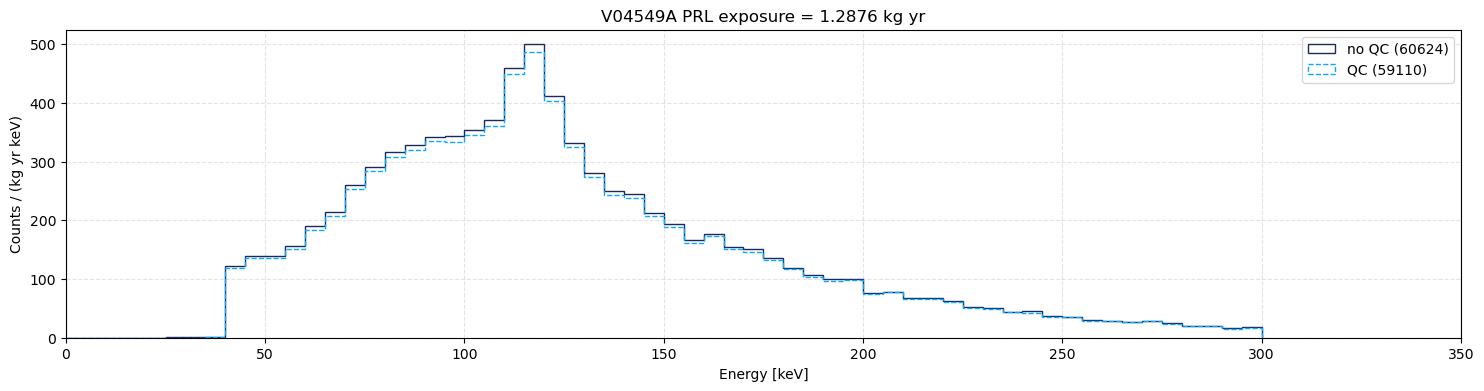

In [23]:
fig, ax = plt.subplots(figsize=(18, 4))

emin, emax = 0, 300
bin_width = 5
bins = np.arange(emin, emax + bin_width, bin_width)

exp = exposures[detector]
scale = exp * bin_width

# Histogramma no QC
ax.hist(
    ene,
    bins=bins,
    weights=np.ones_like(ene) / scale,
    histtype='step',
    color=deepblue,
    label=f"no QC ({len(ene)})"
)

# Histogramma QC
ax.hist(
    ene_bb,
    bins=bins,
    weights=np.ones_like(ene_bb) / scale,
    histtype='step',
    color=deeplightblue,
    linestyle='--',
    label=f"QC ({len(ene_bb)})"
)

ax.set_ylabel("Counts / (kg yr keV)")
ax.set_xlabel("Energy [keV]")
ax.set_xlim(emin, emax+50)
ax.grid(linestyle='--', alpha=0.35)
ax.legend()
ax.set_title(f"{detector} PRL exposure = {exp:.4f} kg yr")

plt.show()

# Lookin per period

In [63]:
def compute_exposure_by_period(runs,  detector=None):
    exposures_by_period = {}

    for period, run_list in runs.items():
        exposures_by_period.setdefault(period, {})

        for run in run_list:
            runinfo = lmeta.dataprod.runinfo[period][run].phy
            chmap = lmeta.channelmap(runinfo.start_key)

            chmap = chmap.group("system").geds.group("analysis.usability").on

            for _, gedet in chmap.items():
                name = gedet.name

                exposure = (
                    gedet.production.mass_in_g
                    / 1000
                    * runinfo.livetime_in_s
                    / 60
                    / 60
                    / 24
                    / 365
                )

                exposures_by_period[period].setdefault(name, 0)
                exposures_by_period[period][name] += exposure

    # filtro opzionale
    if detector is not None:
        filtered = {}
        for period, dets in exposures_by_period.items():
            if detector in dets:
                filtered[period] = dets[detector]
            else:
                filtered[period] = 0
        return filtered

    return exposures_by_period

In [66]:
p = compute_exposure_by_period(runs,  detector)
p

{'p03': 0.15505923706240488,
 'p04': 0.09223951357179096,
 'p06': 0.21346753234398783,
 'p07': 0.18606122653475393,
 'p08': 0.45978911466260786,
 'p09': 0.1810151934297311}

In [73]:
def looking_per_period(p):
    pet_files = sorted(glob.glob(f"{config['tier_pet']}/phy/l200-p0{p}-*-phy-tier_pet.lh5"))

    data_init = lh5.read_as(
        "/evt",
        pet_files,
        field_mask=["coincident", "geds", "trigger"],
        library="ak"
    )

    data = data_init[
        ~data_init.trigger.is_forced &
        ~data_init.coincident.puls &
        ~data_init.coincident.muon_offline &
        ~data_init.geds.quality.is_not_bb_like.is_delayed_discharge &
        data_init.coincident.geds &
        ak.all(data_init.geds.quality.is_good_channel, axis=-1)
    ]

    mydet = (ak.num(data.geds.rawid, axis=1) == 1) & (data.geds.rawid[:, 0] == chn)
    events = data[mydet]

    ene = events.geds.energy
    ene = ene[ak.any(events.geds.rawid == chn, axis=1)]

    ene_bb = ene[events.geds.quality.is_bb_like]

    return ene, ene_bb

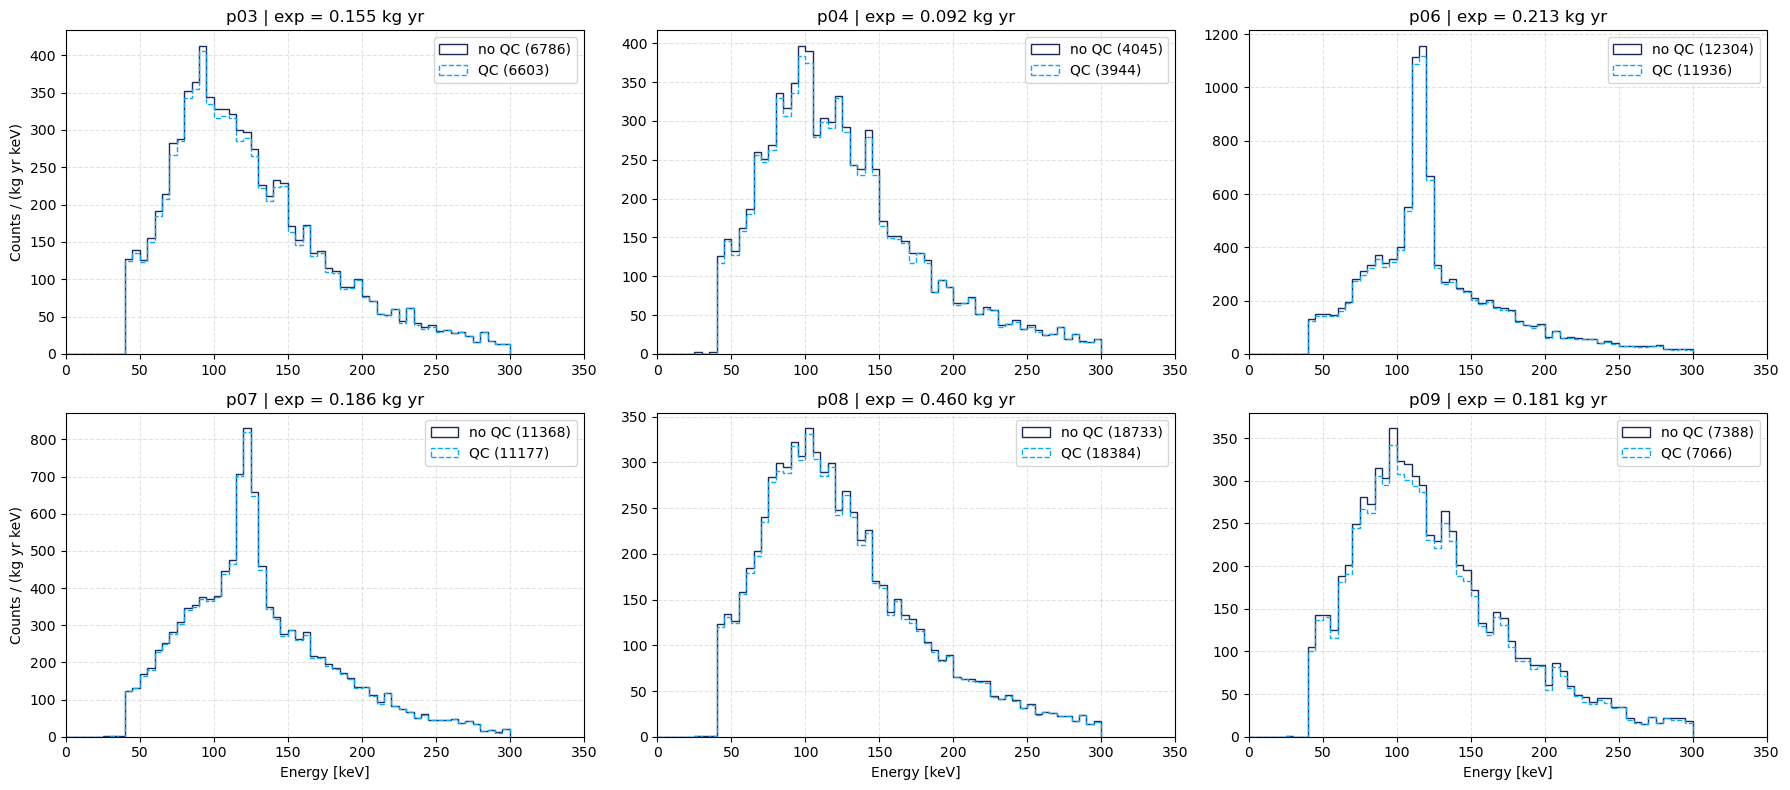

In [77]:
periods = [3, 4, 6, 7, 8, 9]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

emin, emax = 0, 300
bin_width = 5
bins = np.arange(emin, emax + bin_width, bin_width)

exposure = compute_exposure_by_period(runs,  detector)

for i, p in enumerate(periods):
    ax = axes[i]

    ene, ene_bb = looking_per_period(p)
                                          
    exp = exposure[f"p0{p}"]

    scale = exp * bin_width

    ax.hist(
        ene,
        bins=bins,
        weights=np.ones_like(ene) / scale,
        histtype='step',
        color=deepblue,
        label=f"no QC ({len(ene)})"
    )

    ax.hist(
        ene_bb,
        bins=bins,
        weights=np.ones_like(ene_bb) / scale,
        histtype='step',
        color=deeplightblue,
        linestyle='--',
        label=f"QC ({len(ene_bb)})"
    )

    ax.set_title(f"p0{p} | exp = {exp:.3f} kg yr")
    ax.set_xlim(emin, emax + 50)
    ax.grid(linestyle='--', alpha=0.35)

    if i % 3 == 0:
        ax.set_ylabel("Counts / (kg yr keV)")
    if i >= 3:
        ax.set_xlabel("Energy [keV]")

    ax.legend()

plt.tight_layout()
plt.show()

# looking per run

In [103]:
def compute_exposure_by_period_and_run(runs, detector=None):
    exposures = {}

    for period, run_list in runs.items():
        exposures.setdefault(period, {})

        for run in run_list:
            exposures[period].setdefault(run, {})

            runinfo = lmeta.dataprod.runinfo[period][run].phy
            chmap = lmeta.channelmap(runinfo.start_key)

            chmap = chmap.group("system").geds.group("analysis.usability").on

            for _, gedet in chmap.items():
                name = gedet.name

                exposure = (
                    gedet.production.mass_in_g
                    / 1000
                    * runinfo.livetime_in_s
                    / 60
                    / 60
                    / 24
                    / 365
                )

                exposures[period][run].setdefault(name, 0)
                exposures[period][run][name] += exposure

    # filtro opzionale per detector
    if detector is not None:
        filtered = {}
        for period, runs_dict in exposures.items():
            filtered[period] = {}
            for run, dets in runs_dict.items():
                filtered[period][run] = dets[detector]
        return filtered

    return exposures

In [94]:
def looking_per_period_and_run(period, run, chn):

    pet_files = sorted(glob.glob(
        f"{config['tier_pet']}/phy/l200-{period}-{run}-phy-tier_pet.lh5"
    ))

     # 🚨 FIX: controllo file mancanti
    if len(pet_files) == 0:
        print(f"[WARNING] No files for p{period} r{run}")
        return ak.Array([]), ak.Array([])

    

    data_init = lh5.read_as(
        "/evt",
        pet_files,
        field_mask=["coincident", "geds", "trigger"],
        library="ak"
    )

    data = data_init[
        ~data_init.trigger.is_forced &
        ~data_init.coincident.puls &
        ~data_init.coincident.muon_offline &
        ~data_init.geds.quality.is_not_bb_like.is_delayed_discharge &
        data_init.coincident.geds &
        ak.all(data_init.geds.quality.is_good_channel, axis=-1)
    ]

    mydet = (ak.num(data.geds.rawid, axis=1) == 1) & (data.geds.rawid[:, 0] == chn)
    events = data[mydet]

    ene = events.geds.energy
    ene = ene[ak.any(events.geds.rawid == chn, axis=1)]

    ene_bb = ene[events.geds.quality.is_bb_like]

    return ene, ene_bb

In [130]:

def plot_period_all_runs(period_id, runs, detector, chn,
                         emin=0, emax=300, bin_width=5):

    detector = "V04549A"
    bins = np.arange(emin, emax + bin_width, bin_width)

    run_list = runs[period_id]
    n_runs = len(run_list)

    # disposizione subplot (griglia quadrata-ish)
    ncols = int(np.ceil(np.sqrt(n_runs)))
    nrows = int(np.ceil(n_runs / ncols))

    exposure = compute_exposure_by_period_and_run(
        {period_id: run_list},
        detector
    )

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    #colors = plt.cm.viridis(np.linspace(0, 1, n_runs))

    for i, run in enumerate(run_list):

        ax = axes[i]

        ene, ene_bb = looking_per_period_and_run(period_id, run, chn)

        exp = exposure[period_id][run]
        scale = exp * bin_width

        ax.hist(
            ene,
            bins=bins,
            weights=np.ones_like(ene) / scale,
            histtype="step",
            color=deepblue,
            label="no QC"
        )

        ax.hist(
            ene_bb,
            bins=bins,
            weights=np.ones_like(ene_bb) / scale,
            histtype="step",
            linestyle="--",
            color=deeplightblue,
            label="QC"
        )

        ax.set_title(f"{period_id}-{run} | exp = {exp:.3f} kg yr")
        ax.grid(alpha=0.3, linestyle="--")
        ax.legend(fontsize=8)

    # spegni assi vuoti
    for j in range(n_runs, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Period {period_id}", y=1.02)
    for i, ax in enumerate(axes[:n_runs]):
        ax.set_xlim(emin, emax)
        ax.grid(alpha=0.3, linestyle="--")
    
        if i % ncols == 0:
            ax.set_ylabel("Counts / (kg yr keV)")
    
        if i >= n_runs - ncols:
            ax.set_xlabel("Energy [keV]")
        else:
            ax.set_xticklabels([])

    plt.tight_layout()
    plt.show()

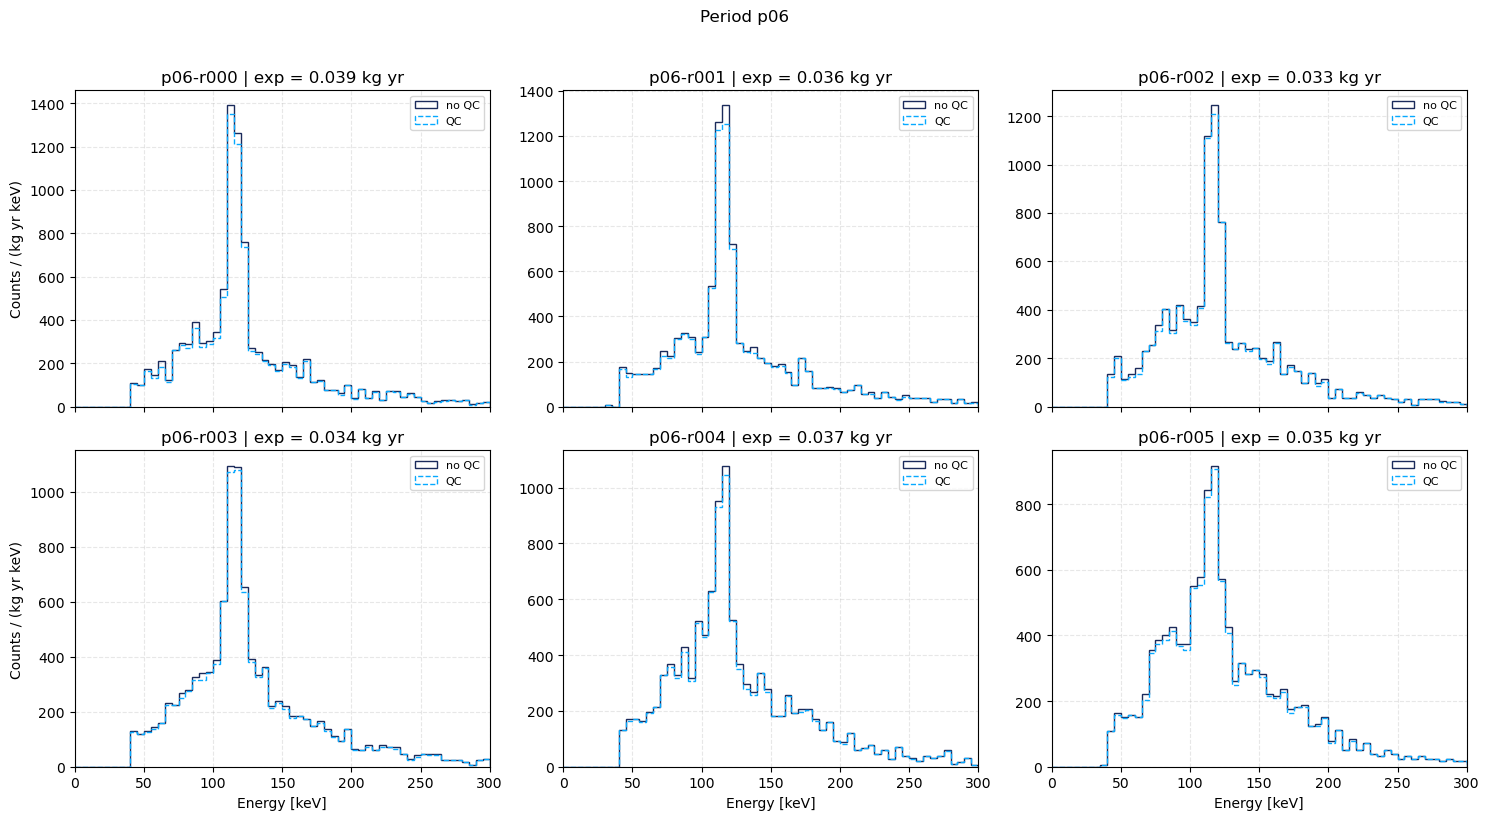

In [131]:
plot_period_all_runs("p06", runs, detector, chn)

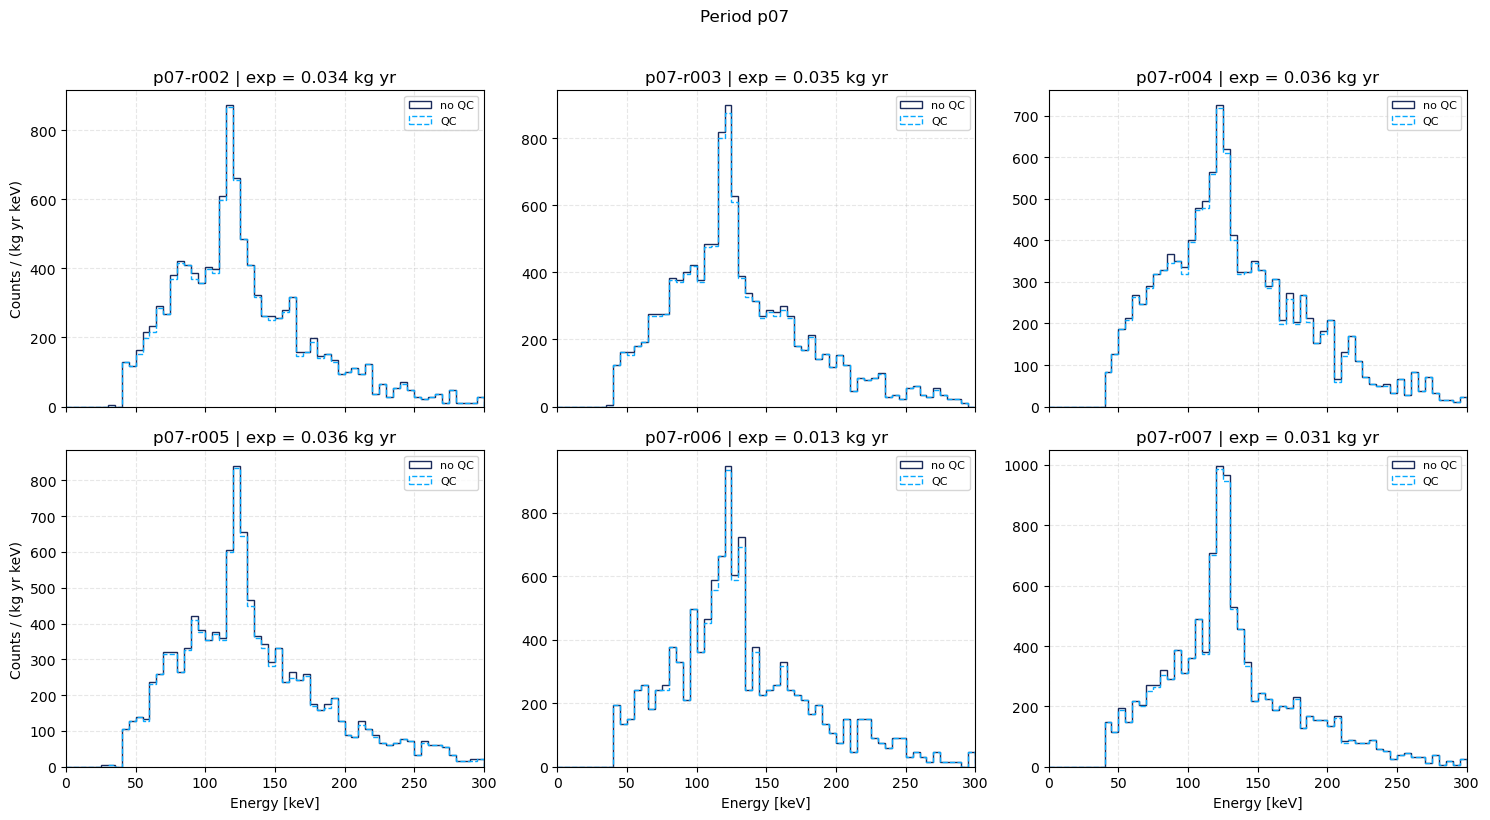

In [132]:
plot_period_all_runs("p07", runs, detector, chn)